In [1]:
# -*- coding: utf-8 -*-
# ============================================================================
#  اسکریپتِ تشخیصیِ داده — قبل از تصمیم‌گیری دربارهٔ مقاله
#  ----------------------------------------------------------------------------
#  این اسکریپت دو سؤالِ تعیین‌کننده را جواب می‌دهد:
#    (A) آیا جفت‌داروها در چند ردهٔ سلولی تکرار می‌شوند؟  → آیا مسیرِ «هم‌افزاییِ
#        وابسته به سلول / leave-cell-out» اصلاً روی این داده ممکن است؟
#    (D) آیا جمله‌های c2s_treated_* احتمالاً «تولید/پیش‌بینی‌شده»‌اند یا
#        «اندازه‌گیری‌شده»؟  (با آزمونِ جبری‌بودن: آیا تابعِ قطعیِ (cell, drug)اند؟)
#  به‌علاوهٔ چند سنجهٔ مکمل:
#    (B) آیا برچسبِ یک جفت بینِ سلول‌ها تغییر می‌کند؟ (شاهدِ مستقیمِ اهمیتِ سلول)
#    (C) آیا نرخِ هم‌افزایی بینِ سلول‌ها پخش است؟ (سیگنالِ هویتِ سلول)
#    (E) آیا برچسب با هویتِ تک‌داروها قابلِ حدس است؟ (شاهدِ غلبهٔ ساختارِ دارو)
#
#  نیازمندی‌ها:  pip install pandas numpy rdkit
#  بدونِ نیاز به torch / GPU. روی همان داده اجرا شود.
# ============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger

RDLogger.DisableLog("rdApp.*")

# مسیر داده — در صورت نیاز ویرایش کنید (همان مسیرِ مدل)
DATA_PATH = r"C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv"

NULLISH = {"", "none", "nan", "null", "na", "n/a", "undefined", "missing"}
gene_cols = [
    "cell_sentence",
    "c2s_treated_d1_sentence",
    "c2s_treated_d2_sentence",
    "c2s_treated_d12_direct",
]


def clean_text(x):
    if x is None:
        return ""
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return ""
    return s


def clean_smiles_string(x):
    if x is None:
        return None
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return None
    return s


def standardize_smiles_rdkit(s):
    s = clean_smiles_string(s)
    if not s:
        return None
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        return None
    try:
        from rdkit.Chem.MolStandardize import rdMolStandardize
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None


def make_binary_label(df_):
    out = pd.Series([np.nan] * len(df_), index=df_.index, dtype="float")
    mapping = {"synergy": 1, "antagonism": 0, "1": 1, "0": 0,
               "true": 1, "false": 0, "yes": 1, "no": 0}
    if "label" in df_.columns:
        num = pd.to_numeric(df_["label"], errors="coerce")
        mapped = df_["label"].astype(str).str.strip().str.lower().map(mapping)
        out = num.fillna(mapped)
    if out.isna().any() and "classification" in df_.columns:
        mapped = df_["classification"].astype(str).str.strip().str.lower().map(mapping)
        out = out.fillna(mapped)
    return out


def load_and_prepare():
    df_path = Path(DATA_PATH)
    if not df_path.exists():
        # چند مسیرِ جایگزین
        for cand in [Path.cwd() / "df_with_c2s.csv.gz",
                     Path.cwd() / "c2s27b_out_0_4396_in300_out300 (2).csv"]:
            if cand.exists():
                df_path = cand
                break
    if not df_path.exists():
        raise FileNotFoundError(f"فایل داده پیدا نشد: {DATA_PATH}")
    is_gz = str(df_path).endswith(".gz")
    print("Using data file:", df_path)

    cols = pd.read_csv(df_path, compression="gzip" if is_gz else None, nrows=0).columns.tolist()
    usecols = ["cell", "drug1_smiles", "drug2_smiles"] + gene_cols
    if "label" in cols:
        usecols.append("label")
    if "classification" in cols:
        usecols.append("classification")
    usecols = [c for c in usecols if c in cols]

    df = pd.read_csv(df_path, compression="gzip" if is_gz else None, usecols=usecols)
    df["label"] = make_binary_label(df)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    df["label"] = df["label"].astype(float).round().astype(int).clip(0, 1)
    df["cell"] = df["cell"].astype(str)
    for c in gene_cols:
        if c in df.columns:
            df[c] = df[c].apply(clean_text)

    # استانداردسازی SMILES — عیناً مثل مدل، تا تعریفِ «جفت» یکسان باشد
    print("Standardizing SMILES (برای تعریفِ هم‌سانِ جفت‌دارو)...")
    s1 = df["drug1_smiles"].apply(standardize_smiles_rdkit)
    s2 = df["drug2_smiles"].apply(standardize_smiles_rdkit)
    df["drug1_smiles"] = s1
    df["drug2_smiles"] = s2
    df = df[df["drug1_smiles"].notna() & df["drug2_smiles"].notna()].reset_index(drop=True)

    df["drug_pair"] = df.apply(
        lambda r: "||".join(sorted([r["drug1_smiles"], r["drug2_smiles"]])), axis=1)
    return df


def hr(title=""):
    print("\n" + "=" * 72)
    if title:
        print(title)
        print("=" * 72)


def section_A_pair_repetition(df):
    hr("‏(A) تکرارِ جفت‌دارو در چند سلول  →  آیا مسیرِ ۲ (وابسته به سلول) ممکن است؟")
    n_rows = len(df)
    g = df.groupby("drug_pair")
    n_rows_per_pair = g.size()
    n_cells_per_pair = g["cell"].nunique()
    n_pairs = len(n_rows_per_pair)

    print(f"کل ردیف‌ها: {n_rows}  |  جفت‌های یکتا: {n_pairs}  |  "
          f"میانگین ردیف به‌ازای هر جفت: {n_rows / n_pairs:.3f}")
    print("توزیعِ تعدادِ سلولِ متمایز به‌ازای هر جفت:")
    vc = n_cells_per_pair.value_counts().sort_index()
    for k, v in vc.items():
        print(f"   در {int(k)} سلول دیده شده:  {v} جفت  ({100*v/n_pairs:.1f}% از جفت‌ها)")

    multi_idx = n_cells_per_pair[n_cells_per_pair >= 2].index
    n_multi = len(multi_idx)
    rows_in_multi = int(n_rows_per_pair[multi_idx].sum())
    print(f"\n>>> جفت‌هایی که در ≥۲ سلول ظاهر شده‌اند: {n_multi}  "
          f"({100*n_multi/n_pairs:.1f}% از جفت‌ها)")
    print(f">>> سهمِ ردیف‌هایی که به این جفت‌های چندسلولی تعلق دارند: "
          f"{rows_in_multi} از {n_rows}  ({100*rows_in_multi/n_rows:.1f}%)")
    return {"n_rows": n_rows, "n_pairs": n_pairs, "n_multi": n_multi,
            "rows_in_multi_frac": rows_in_multi / n_rows, "multi_idx": multi_idx,
            "n_rows_per_pair": n_rows_per_pair}


def section_B_label_flip(df, multi_idx):
    hr("‏(B) آیا برچسبِ یک جفت بینِ سلول‌ها تغییر می‌کند؟  →  شاهدِ مستقیمِ اهمیتِ سلول")
    if len(multi_idx) == 0:
        print("هیچ جفتی در ≥۲ سلول وجود ندارد؛ این آزمون قابلِ اجرا نیست.")
        return {"n_flip": 0, "rows_in_flip_frac": 0.0}
    sub = df[df["drug_pair"].isin(multi_idx)]
    g = sub.groupby("drug_pair")
    n_labels = g["label"].nunique()
    flip_idx = n_labels[n_labels >= 2].index
    n_flip = len(flip_idx)
    rows_in_flip = int(g.size()[flip_idx].sum()) if n_flip > 0 else 0
    print(f"از {len(multi_idx)} جفتِ چندسلولی، تعدادی که برچسبِ متفاوت در سلول‌های "
          f"مختلف دارند (synergy در یکی، antagonism در دیگری): {n_flip}")
    print(f"سهمِ ردیف‌های مربوط به این جفت‌های «برچسب‌متغیر»: "
          f"{rows_in_flip} ({100*rows_in_flip/len(df):.1f}% از کلِ داده)")
    if n_flip > 0:
        print("\nچند نمونه (SMILES کوتاه‌شده):")
        shown = 0
        for pair in flip_idx:
            rows = sub[sub["drug_pair"] == pair]
            combos = sorted(set(zip(rows["cell"], rows["label"])))
            short = pair[:22] + "…||…" + pair[-10:]
            combo_str = ", ".join(f"{c}:{int(l)}" for c, l in combos[:6])
            print(f"   {short}  →  {combo_str}")
            shown += 1
            if shown >= 5:
                break
    return {"n_flip": n_flip, "rows_in_flip_frac": rows_in_flip / len(df)}


def section_C_cell_rate(df):
    hr("‏(C) پراکندگیِ نرخِ هم‌افزایی بینِ سلول‌ها  →  آیا هویتِ سلول به‌تنهایی سیگنال دارد؟")
    cr = df.groupby("cell")["label"].agg(["mean", "size"]).sort_values("size", ascending=False)
    big = cr[cr["size"] >= 20]
    print(f"تعدادِ سلول‌ها: {len(cr)}  |  سلول‌هایی با ≥۲۰ نمونه: {len(big)}")
    if len(big) >= 2:
        print(f"نرخِ هم‌افزایی در این سلول‌ها — کمینه {big['mean'].min():.2f}  "
              f"بیشینه {big['mean'].max():.2f}  انحرافِ معیار {big['mean'].std():.3f}")
        print("‏(انحرافِ معیارِ بزرگ یعنی صرفاً «این سلول» بدونِ ژن هم پیش‌بینی‌کننده است.)")
        print("‏۵ سلولِ پرنمونه:")
        for cell, row in big.head(5).iterrows():
            print(f"   {str(cell)[:24]:24s}  n={int(row['size']):4d}  synergy-rate={row['mean']:.2f}")
    else:
        print("سلول‌های پرنمونهٔ کافی برای این تحلیل وجود ندارد.")
    base_rate = df["label"].mean()
    print(f"\nنرخِ کلیِ هم‌افزایی (base rate): {base_rate:.3f}  "
          f"→ دقتِ «همیشه کلاسِ اکثریت»: {max(base_rate, 1-base_rate):.3f}")
    return {"base_rate": base_rate}


def determinism(df, group_cols, text_col):
    """نسبتِ گروه‌هایی که در آن‌ها text_col فقط یک مقدارِ یکتا دارد (جبری/قطعی)."""
    if text_col not in df.columns:
        return None
    sub = df[df[text_col].astype(str) != ""]  # ردیف‌های خالی را کنار بگذار
    if len(sub) == 0:
        return None
    nun = sub.groupby(group_cols)[text_col].nunique()
    n_groups = len(nun)
    n_det = int((nun <= 1).sum())
    n_multi_row = int((sub.groupby(group_cols).size() >= 2).sum())  # گروه‌های دارای ≥۲ ردیف
    empty_frac = float((df[text_col].astype(str) == "").mean())
    return {"n_groups": n_groups, "n_det": n_det, "frac_det": n_det / n_groups,
            "n_multi_row_groups": n_multi_row, "empty_frac": empty_frac}


def section_D_gene_origin(df):
    hr("‏(D) منشأ جمله‌های ژنی: تولید‌شده یا اندازه‌گیری‌شده؟  (آزمونِ جبری‌بودن)")
    print("منطق: اگر یک جمله، تابعِ کاملاً قطعیِ (cell, drug) باشد (هیچ نویز/تکرارِ "
          "متفاوتی نداشته باشد)، تقریباً حتماً تولید/پیش‌بینی‌شده است؛ دادهٔ اندازه‌گیریِ "
          "واقعی معمولاً بینِ تکرارها تفاوت دارد.\n")

    checks = [
        ("cell_sentence", ["cell"], "بیانِ پایهٔ سلول → تابعِ (cell)؟"),
        ("c2s_treated_d1_sentence", ["cell", "drug1_smiles"], "تیمار با داروی ۱ → تابعِ (cell, drug1)؟"),
        ("c2s_treated_d2_sentence", ["cell", "drug2_smiles"], "تیمار با داروی ۲ → تابعِ (cell, drug2)؟"),
        ("c2s_treated_d12_direct", ["cell", "drug1_smiles", "drug2_smiles"], "تیمار با هر دو → تابعِ (cell, d1, d2)؟"),
    ]
    flags = []
    for col, grp, desc in checks:
        r = determinism(df, grp, col)
        if r is None:
            print(f" - {desc}\n     (ستون موجود نیست یا همه خالی است)")
            continue
        print(f" - {desc}")
        print(f"     گروه‌های قطعی: {r['n_det']}/{r['n_groups']} "
              f"({100*r['frac_det']:.1f}%)  |  گروه‌های دارای ≥۲ ردیف: {r['n_multi_row_groups']}  "
              f"|  ردیف‌های خالی: {100*r['empty_frac']:.1f}%")
        # فقط وقتی معنادار است که گروه‌های چندردیفی وجود داشته باشند
        flags.append((r["frac_det"], r["n_multi_row_groups"]))

    informative = [f for f, m in flags if m >= 5]
    print("\n>>> تفسیر:")
    if not informative:
        print("    هشدار: تقریباً همهٔ گروه‌ها فقط یک ردیف دارند، پس این آزمون قاطع نیست.")
        print("    (چون هر (cell,drug) تقریباً یکتاست، نمی‌توان قطعی/نویزی بودن را سنجید.")
        print("     این خودش تأییدِ ساختارِ «cold-pair» است — منشأ را باید از سازندهٔ داده پرسید.)")
    elif min(informative) > 0.98:
        print("    جمله‌ها تقریباً کاملاً قطعی‌اند → به‌احتمالِ زیاد تولید/پیش‌بینی‌شده‌اند،")
        print("    یعنی جریانِ ژن تا حد زیادی تابعِ (cell, drug) است و اطلاعاتِ مستقلِ کمی")
        print("    فراتر از خودِ داروها اضافه می‌کند — سازگار با نتیجهٔ ضعیفِ ablation.")
    else:
        print(f"    حداقلِ نرخِ قطعی‌بودن در گروه‌های چندردیفی: {min(informative):.2f}")
        print("    اگر «به‌وضوح کمتر از ۱» است یعنی تفاوت/نویز وجود دارد → احتمالِ دادهٔ اندازه‌گیریِ")
        print("    واقعی بیشتر است؛ آن‌وقت سیگنالِ ضعیفِ ژن یک معمای جالب‌تر برای بررسی است.")


def section_E_single_drug(df):
    hr("‏(E) آیا برچسب با هویتِ تک‌داروها قابلِ حدس است؟  →  شاهدِ غلبهٔ ساختارِ دارو")
    long = pd.concat([
        df[["drug1_smiles", "label"]].rename(columns={"drug1_smiles": "drug"}),
        df[["drug2_smiles", "label"]].rename(columns={"drug2_smiles": "drug"}),
    ], ignore_index=True)
    g = long.groupby("drug")["label"]
    counts = g.size()
    means = g.mean()
    frequent = counts[counts >= 5].index
    if len(frequent) == 0:
        print("داروی پرتکرارِ کافی وجود ندارد.")
        return
    pure = means[frequent]
    n_pure = int(((pure <= 0.1) | (pure >= 0.9)).sum())
    print(f"داروهای یکتا (پس از باز کردنِ جفت‌ها به تک‌دارو): {counts.shape[0]}  |  "
          f"داروهایی با ≥۵ ظهور: {len(frequent)}")
    print(f"از این داروهای پرتکرار، چند تا تقریباً «تک‌برچسب» هستند "
          f"(نرخِ هم‌افزایی ≤۰٫۱ یا ≥۰٫۹): {n_pure}  ({100*n_pure/len(frequent):.1f}%)")
    print("‏(درصدِ بالا یعنی صِرفِ دانستنِ یک داروی موجود در جفت، اغلب برچسب را تعیین می‌کند؛")
    print(" یعنی ساختارِ دارو سیگنالِ غالب است — همان چیزی که در ablation دیدیم.)")


def final_verdict(A, B):
    hr("‏جمع‌بندیِ تشخیصی  →  کدام مسیر روی میز است؟")
    frac_multi = A["rows_in_multi_frac"]
    frac_flip = B["rows_in_flip_frac"]
    print(f"• سهمِ دادهٔ مربوط به جفت‌های چندسلولی: {100*frac_multi:.1f}%")
    print(f"• سهمِ دادهٔ مربوط به جفت‌های «برچسب‌متغیر بینِ سلول‌ها»: {100*frac_flip:.1f}%")
    print("")
    if frac_multi < 0.05:
        print("‏⛔ مسیر ۲ (هم‌افزاییِ وابسته به سلول / leave-cell-out روی جفت‌های تکراری):")
        print("    عملاً ممکن نیست — تقریباً هیچ جفتی در چند سلول تکرار نشده.")
        print("    → مسیر ۱ (نتیجهٔ صادقانهٔ cold-pair + چند seed + DeLong) ستونِ فقراتِ شماست.")
        print("    → برای تقویت، مسیر ۳ (نمایشِ بهترِ ژن: CCLE/scGPT) یا یک baselineِ قویِ")
        print("       XGBoost را در نظر بگیرید، نه شکارِ هایپرپارامتر.")
    elif frac_flip < 0.02:
        print("‏⚠️ جفت‌ها کمی تکرار می‌شوند ولی برچسب‌شان تقریباً هیچ‌وقت بینِ سلول‌ها عوض نمی‌شود.")
        print("    → سلول/ژن سیگنالِ تمایزدهندهٔ کمی دارد؛ مسیر ۱ امن‌ترین است.")
    else:
        print("‏✅ بخشِ معناداری از داده، جفت‌هایی است که برچسب‌شان بینِ سلول‌ها تغییر می‌کند.")
        print("    → مسیر ۲ روی میز است: یک split به‌صورتِ leave-cell-out یا تمرکز روی همین")
        print("       زیرمجموعهٔ «وابسته به سلول» می‌تواند نتیجهٔ قوی‌تر و بدیع‌تری بدهد که در آن")
        print("       ژن واقعاً اهمیت پیدا می‌کند.")
    print("\nنکته: بخشِ (D) را هم بخوانید — اگر جمله‌های ژنی تولید/پیش‌بینی‌شده باشند،")
    print("این محدودیت را باید صریحاً در مقاله ذکر کنید.")


def main():
    df = load_and_prepare()
    print(f"\nردیف‌های نهاییِ تحلیل: {len(df)}  |  سلول‌ها: {df['cell'].nunique()}  |  "
          f"نرخِ هم‌افزایی: {df['label'].mean():.3f}")
    A = section_A_pair_repetition(df)
    B = section_B_label_flip(df, A["multi_idx"])
    section_C_cell_rate(df)
    section_D_gene_origin(df)
    section_E_single_drug(df)
    final_verdict(A, B)


if __name__ == "__main__":
    main()

Using data file: C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv
Standardizing SMILES (برای تعریفِ هم‌سانِ جفت‌دارو)...

ردیف‌های نهاییِ تحلیل: 3885  |  سلول‌ها: 52  |  نرخِ هم‌افزایی: 0.319

‏(A) تکرارِ جفت‌دارو در چند سلول  →  آیا مسیرِ ۲ (وابسته به سلول) ممکن است؟
کل ردیف‌ها: 3885  |  جفت‌های یکتا: 3841  |  میانگین ردیف به‌ازای هر جفت: 1.011
توزیعِ تعدادِ سلولِ متمایز به‌ازای هر جفت:
   در 1 سلول دیده شده:  3797 جفت  (98.9% از جفت‌ها)
   در 2 سلول دیده شده:  44 جفت  (1.1% از جفت‌ها)

>>> جفت‌هایی که در ≥۲ سلول ظاهر شده‌اند: 44  (1.1% از جفت‌ها)
>>> سهمِ ردیف‌هایی که به این جفت‌های چندسلولی تعلق دارند: 88 از 3885  (2.3%)

‏(B) آیا برچسبِ یک جفت بینِ سلول‌ها تغییر می‌کند؟  →  شاهدِ مستقیمِ اهمیتِ سلول
از 44 جفتِ چندسلولی، تعدادی که برچسبِ متفاوت در سلول‌های مختلف دارند (synergy در یکی، antagonism در دیگری): 30
سهمِ ردیف‌های مربوط به این جفت‌های «برچسب‌متغیر»: 60 (1.5% از کلِ داده)

چند نمونه (SMILES کوتاه‌شده):
   C#Cc1cccc(Nc

Using data file: C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv
Shape raw: (4268, 8) | Unique cells: 52 | label: {0: 2929, 1: 1339}
SMILES standardization: dropped 383 invalid rows
After standardize: (3885, 8)
Computing Morgan fingerprints...
Done.
CV rows: 3108, Test rows: 777
CV unique drug pairs: 3072, Test unique drug pairs: 769

🚀 شروع ارزیابی ۵‑فولد برای مدل کامل (Drug+Gene)

FULL - FOLD 1/5
Epoch   1 | Train Loss 0.9487 Acc 0.5390 | Val Loss 0.9390 | F1@0.5 0.5254 | Val AUC 0.6929
Epoch   2 | Train Loss 0.9397 Acc 0.5495 | Val Loss 0.9154 | F1@0.5 0.5571 | Val AUC 0.7243
Epoch   3 | Train Loss 0.9252 Acc 0.6183 | Val Loss 0.8820 | F1@0.5 0.5651 | Val AUC 0.7337
Epoch   4 | Train Loss 0.8939 Acc 0.6838 | Val Loss 0.8432 | F1@0.5 0.5573 | Val AUC 0.7402
Epoch   5 | Train Loss 0.8584 Acc 0.6858 | Val Loss 0.8197 | F1@0.5 0.5534 | Val AUC 0.7421
Epoch   6 | Train Loss 0.8246 Acc 0.7120 | Val Loss 0.8124 | F1@0.5 0.5574 | Va

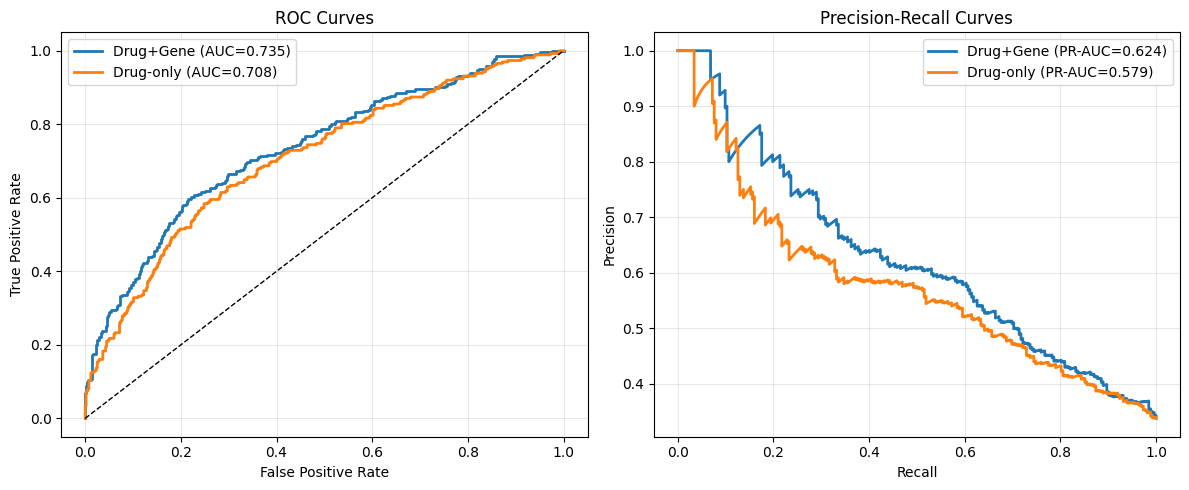

✅ نمودارهای ROC و PR ذخیره شدند: roc_pr_comparison.png

📋 خلاصه نهایی برای مقاله:
بهترین فراپارامترها: alpha=0.3, lr=5e-05, word_dropout=0.3
مدل کامل (Drug+Gene) - Test AUC: 0.7350, F1: 0.5869
مدل پایه (Drug-only) - Test AUC: 0.7084, F1: 0.5680
ΔAUC = 0.0266 (p=0.0501)


In [1]:
# ============================================================
# ✅ کد جامع برای مقایسه مدل کامل (Drug+Gene) و مدل پایه (Drug-only)
# ------------------------------------------------------------
# شامل:
#   - بارگذاری و پیش‌پردازش داده
#   - تعریف هر دو مدل
#   - اعتبارسنجی ۵‑فولد با ذخیره معیارهای هر فولد
#   - محاسبه میانگین، انحراف معیار و p‑value
#   - ارزیابی نهایی روی تست با ensemble و تعیین آستانه بهینه
#   - رسم نمودارهای ROC و Precision‑Recall
# ============================================================

import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix, f1_score, roc_auc_score
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from scipy.stats import ttest_rel
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from rdkit import Chem, RDLogger
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import time
import warnings
warnings.filterwarnings('ignore')

RDLogger.DisableLog("rdApp.*")

# ----------------------------------------------
# 1) تنظیمات پایه (مشترک)
# ----------------------------------------------
ROOT = Path.cwd()
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0
NUM_EPOCHS_FINAL = 100
PATIENCE_FINAL = 5
FP_RADIUS = 2
FP_NBITS = 1024
GENE_LEN = 300
gene_cols = [
    "cell_sentence",
    "c2s_treated_d1_sentence",
    "c2s_treated_d2_sentence",
    "c2s_treated_d12_direct",
]
RANK_WEIGHT_MODE = "inv"
RANK_LEARNABLE_WEIGHTS = True
GENE_D_MODEL = 256
D_SHARED = 256
FUSION_HEADS = 4
FUSION_LAYERS = 2
FUSION_DROPOUT = 0.30
NUM_WORKERS = 0
USE_CELL_EMB = False
MONITOR = "auc"
NULLISH = {"", "none", "nan", "null", "na", "n/a", "undefined", "missing"}

# بهترین فراپارامترهای به‌دست‌آمده از جستجو (از خروجی قبلی)
BEST_ALPHA = 0.3
BEST_LR = 5e-5
BEST_DROPOUT = 0.3

# ----------------------------------------------
# 2) توابع کمکی پایه (همانند قبل)
# ----------------------------------------------
def _make_rank_weights(max_len, mode="inv", alpha=0.3, beta=0.03):
    i = torch.arange(max_len, dtype=torch.float32)
    if mode == "linear":
        w = (max_len - i) / max_len
    elif mode == "inv":
        w = 1.0 / (1.0 + i) ** alpha
    else:
        w = torch.exp(-beta * i)
    w = w / (w.sum() + 1e-12)
    return w

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def clean_text(x):
    if x is None:
        return ""
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return ""
    return s

def clean_smiles_string(x):
    if x is None:
        return None
    s = str(x).strip()
    if (not s) or (s.lower() in NULLISH):
        return None
    return s

def split_genes(text: str):
    if isinstance(text, str):
        t = text.strip()
        return t.split() if t else []
    return []

def pad_list(ids, target_len, pad_id=0):
    if len(ids) >= target_len:
        return ids[:target_len]
    return ids + [pad_id] * (target_len - len(ids))

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(FP_NBITS, dtype=np.float32)
    gen = GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
    fp = gen.GetFingerprint(mol)
    return np.array(fp, dtype=np.float32)

def standardize_smiles_rdkit(s):
    s = clean_smiles_string(s)
    if not s:
        return None
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        return None
    try:
        from rdkit.Chem.MolStandardize import rdMolStandardize
        lfc = rdMolStandardize.LargestFragmentChooser()
        mol = lfc.choose(mol)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None

def threshold_sweep_0_to_100(y_true, y_prob):
    best_f1 = -1.0
    best_thr = 0.5
    for t_int in range(101):
        thr = t_int / 100.0
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1

def metrics_at_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
    }

# ----------------------------------------------
# 3) بارگذاری داده (مشترک)
# ----------------------------------------------
custom_path = Path(r"C:\Users\afsha\Desktop\modell\finish_6\data\df_without_c2s_cols.csv\c2s27b_out_0_4396_in300_out300 (2).csv")
candidates = [custom_path, ROOT / "df_with_c2s.csv.gz", ROOT / "c2s27b_out_0_4396_in300_out300 (2).csv"]
df_path = next((p for p in candidates if p.exists()), None)
if df_path is None:
    raise FileNotFoundError(f"فایل داده پیدا نشد: {custom_path}")
is_gz = str(df_path).endswith(".gz")
print("Using data file:", df_path)

hdr = pd.read_csv(df_path, compression="gzip" if is_gz else None, nrows=0)
cols = hdr.columns.tolist()

cell_col = "cell" if "cell" in cols else None
d1_col = "drug1_smiles" if "drug1_smiles" in cols else None
d2_col = "drug2_smiles" if "drug2_smiles" in cols else None
label_has = "label" in cols or "classification" in cols
missing_gene = [c for c in gene_cols if c not in cols]

if cell_col is None or d1_col is None or d2_col is None:
    raise ValueError("ستون‌های 'cell'، 'drug1_smiles' یا 'drug2_smiles' وجود ندارند.")
if missing_gene:
    raise ValueError(f"ستون‌های ژنی زیر یافت نشدند: {missing_gene}")
if not label_has:
    raise ValueError("ستون 'label' یا 'classification' وجود ندارد.")

usecols = [cell_col, d1_col, d2_col] + gene_cols
if "label" in cols:
    usecols.append("label")
if "classification" in cols:
    usecols.append("classification")

df = pd.read_csv(df_path, compression="gzip" if is_gz else None, usecols=usecols)

rename_map = {}
if cell_col != "cell":
    rename_map[cell_col] = "cell"
if d1_col != "drug1_smiles":
    rename_map[d1_col] = "drug1_smiles"
if d2_col != "drug2_smiles":
    rename_map[d2_col] = "drug2_smiles"
df = df.rename(columns=rename_map)

def make_binary_label(df_):
    out = pd.Series([np.nan] * len(df_), index=df_.index, dtype="float")
    if "label" in df_.columns:
        s_raw = df_["label"]
        s_str = s_raw.astype(str).str.strip().str.lower()
        num = pd.to_numeric(s_raw, errors="coerce")
        mapped = s_str.map({"synergy":1, "antagonism":0, "1":1, "0":0, "true":1, "false":0, "yes":1, "no":0})
        out = num.fillna(mapped)
    if out.isna().any() and "classification" in df_.columns:
        c = df_["classification"].astype(str).str.strip().str.lower()
        mapped = c.map({"synergy":1, "antagonism":0, "1":1, "0":0, "true":1, "false":0, "yes":1, "no":0})
        out = out.fillna(mapped)
    return out

df["label"] = make_binary_label(df)
need_cols = ["cell", "drug1_smiles", "drug2_smiles", "label"] + gene_cols
df = df[need_cols].copy()

for c in gene_cols:
    df[c] = df[c].apply(clean_text)

df = df.dropna(subset=["label"]).reset_index(drop=True)
df["label"] = df["label"].astype(float).round().astype(int).clip(0,1)
df["cell"] = df["cell"].astype(str)

print("Shape raw:", df.shape, "| Unique cells:", df["cell"].nunique(), "| label:", df["label"].value_counts().to_dict())

def apply_smiles_standardization(df_):
    std1, std2 = [], []
    invalid = 0
    for a,b in zip(df_["drug1_smiles"], df_["drug2_smiles"]):
        a0 = clean_smiles_string(a)
        b0 = clean_smiles_string(b)
        sa = standardize_smiles_rdkit(a0) if a0 else None
        sb = standardize_smiles_rdkit(b0) if b0 else None
        if sa is None or sb is None:
            invalid += 1
            std1.append("")
            std2.append("")
        else:
            std1.append(sa)
            std2.append(sb)
    df_ = df_.copy()
    df_["drug1_smiles_std"] = std1
    df_["drug2_smiles_std"] = std2
    df_ok = df_[(df_["drug1_smiles_std"]!="") & (df_["drug2_smiles_std"]!="")].copy()
    df_ok["drug1_smiles"] = df_ok["drug1_smiles_std"]
    df_ok["drug2_smiles"] = df_ok["drug2_smiles_std"]
    df_ok = df_ok.drop(columns=["drug1_smiles_std","drug2_smiles_std"])
    print(f"SMILES standardization: dropped {invalid} invalid rows")
    return df_ok.reset_index(drop=True)

df = apply_smiles_standardization(df)
print("After standardize:", df.shape)

print("Computing Morgan fingerprints...")
df["fp1"] = df["drug1_smiles"].apply(smiles_to_fingerprint)
df["fp2"] = df["drug2_smiles"].apply(smiles_to_fingerprint)
print("Done.")

df["drug_pair"] = df.apply(
    lambda row: "||".join(sorted([row["drug1_smiles"], row["drug2_smiles"]])),
    axis=1
)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trainval_idx, test_idx = next(gss.split(df, df["label"], groups=df["drug_pair"]))
df_cv = df.iloc[trainval_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)
print(f"CV rows: {len(df_cv)}, Test rows: {len(df_test)}")
print(f"CV unique drug pairs: {df_cv['drug_pair'].nunique()}, Test unique drug pairs: {df_test['drug_pair'].nunique()}")

# ----------------------------------------------
# 4) تعریف Dataset‌ها و مدل‌ها
# ----------------------------------------------
# 4‑الف) Dataset برای مدل کامل (با ژن)
class SynergyDataset(Dataset):
    def __init__(self, df_, training, encode_cell_fn, encode_genes_fn,
                 gene_unk_id, gene_pad_id, gene_word_dropout_p=0.0):
        self.df = df_.reset_index(drop=True)
        self.training = training
        self.encode_cell = encode_cell_fn
        self.encode_genes = encode_genes_fn
        self.GENE_UNK = gene_unk_id
        self.GENE_PAD = gene_pad_id
        self.gene_word_dropout_p = gene_word_dropout_p
        self.gene_cache = {}
        self.fp1_list = df_["fp1"].values
        self.fp2_list = df_["fp2"].values

    def __len__(self):
        return len(self.df)

    def _get_gene(self, sentence):
        sentence = "" if not isinstance(sentence, str) else sentence
        t = self.gene_cache.get(sentence)
        if t is None:
            t = self.encode_genes(sentence)
            self.gene_cache[sentence] = t
        return t.clone()

    def _token_dropout(self, ids, drop_p, unk_id, pad_id):
        if not self.training or drop_p <= 0:
            return ids
        out = ids.clone()
        mask = (torch.rand_like(out.float()) < drop_p) & out.ne(pad_id)
        out[mask] = unk_id
        return out

    def __getitem__(self, i):
        r = self.df.iloc[i]
        cell_id = self.encode_cell(r["cell"])
        g_base = self._get_gene(r["cell_sentence"])
        g_d1 = self._get_gene(r["c2s_treated_d1_sentence"])
        g_d2 = self._get_gene(r["c2s_treated_d2_sentence"])
        g_d12 = self._get_gene(r["c2s_treated_d12_direct"])
        g_base = self._token_dropout(g_base, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d1 = self._token_dropout(g_d1, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d2 = self._token_dropout(g_d2, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        g_d12 = self._token_dropout(g_d12, self.gene_word_dropout_p, self.GENE_UNK, self.GENE_PAD)
        fp1 = torch.tensor(self.fp1_list[i], dtype=torch.float32)
        fp2 = torch.tensor(self.fp2_list[i], dtype=torch.float32)
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y

# 4‑ب) Dataset برای مدل پایه (فقط دارو)
class DrugDataset(Dataset):
    def __init__(self, df_):
        self.fp1 = df_["fp1"].values
        self.fp2 = df_["fp2"].values
        self.y = df_["label"].values.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return (torch.tensor(self.fp1[i], dtype=torch.float32),
                torch.tensor(self.fp2[i], dtype=torch.float32),
                torch.tensor(float(self.y[i]), dtype=torch.float32))

# 4‑ج) مدل کامل (Drug+Gene)
class RankWeightedGeneEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, pad_idx, dropout, max_len, weight_mode,
                 alpha=0.3, beta=0.03, learnable=False):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        self.max_len = max_len
        w = _make_rank_weights(max_len, weight_mode, alpha, beta)
        if learnable:
            self.rank_w = nn.Parameter(w)
        else:
            self.register_buffer("rank_w", w)
        self.weight_mode = weight_mode
        self.alpha = alpha
        self.beta = beta

    def forward(self, ids):
        B, L = ids.shape
        if L != self.max_len:
            w = _make_rank_weights(L, self.weight_mode, self.alpha, self.beta).to(ids.device)
        else:
            w = self.rank_w[:L].to(ids.device)
        pad_mask = ids.eq(self.pad_idx)
        h = self.emb(ids)
        h = self.drop(h)
        ww = w.view(1, L, 1) * (~pad_mask).unsqueeze(-1).float()
        num = (h * ww).sum(dim=1)
        den = ww.sum(dim=1).clamp(min=1e-8)
        out = num / den
        return self.norm(out)

class LightFusionTransformer(nn.Module):
    def __init__(self, d_shared, n_tokens, n_heads, n_layers, dropout):
        super().__init__()
        self.fuse_token = nn.Parameter(torch.zeros(1,1,d_shared))
        self.pos_emb = nn.Parameter(torch.zeros(1,1+n_tokens,d_shared))
        layer = nn.TransformerEncoderLayer(d_model=d_shared, nhead=n_heads, dim_feedforward=4*d_shared,
                                           dropout=dropout, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_shared)
        nn.init.normal_(self.fuse_token, std=0.02)
        nn.init.normal_(self.pos_emb, std=0.02)

    def forward(self, tokens):
        B = tokens.size(0)
        fuse = self.fuse_token.expand(B, -1, -1)
        x = torch.cat([fuse, tokens], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]
        h = self.enc(x)
        h = self.norm(h)
        return h[:,0,:]

class SynergyModelTwoDimGate(nn.Module):
    def __init__(self, vocab_cells, vocab_genes, gene_pad_id, use_cell_emb=False,
                 d_gene=GENE_D_MODEL, d_shared=D_SHARED, alpha=0.3, gene_word_dropout_p=0.3):
        super().__init__()
        self.use_cell_emb = use_cell_emb
        self.d_shared = d_shared
        self.gene_word_dropout_p = gene_word_dropout_p

        if use_cell_emb:
            self.cell_emb = nn.Embedding(vocab_cells, 64)
            cell_dim = 64
        else:
            self.cell_emb = None
            cell_dim = 0

        self.gene_encoder = RankWeightedGeneEncoder(
            vocab_size=vocab_genes, d_model=d_gene, pad_idx=gene_pad_id,
            dropout=0.20, max_len=GENE_LEN, weight_mode=RANK_WEIGHT_MODE,
            alpha=alpha, learnable=RANK_LEARNABLE_WEIGHTS
        )
        self.proj_gene = nn.Linear(d_gene, d_shared, bias=False)
        self.proj_smiles = nn.Linear(FP_NBITS, d_shared, bias=False)
        self.norm = nn.LayerNorm(d_shared)

        self.num_gene_tokens = 5
        self.num_smiles_tokens = 3
        self.num_tokens = self.num_gene_tokens + self.num_smiles_tokens

        context_dim = d_shared + cell_dim
        self.gate_net = nn.Sequential(
            nn.Linear(context_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 2),
            nn.Sigmoid()
        )

        self.fusion = LightFusionTransformer(
            d_shared=d_shared, n_tokens=self.num_tokens,
            n_heads=FUSION_HEADS, n_layers=FUSION_LAYERS,
            dropout=FUSION_DROPOUT
        )

        in_dim = (cell_dim if use_cell_emb else 0) + d_shared
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 256), nn.GELU(), nn.Dropout(0.40),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(128, 1)
        )

    def forward(self, cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2):
        if self.use_cell_emb:
            h_cell = self.cell_emb(cell_id)
        else:
            h_cell = None

        h_base = self.gene_encoder(g_base)
        h_d1   = self.gene_encoder(g_d1)
        h_d2   = self.gene_encoder(g_d2)
        h_d12  = self.gene_encoder(g_d12)

        z_base = self.norm(self.proj_gene(h_base))
        z_d1   = self.norm(self.proj_gene(h_d1))
        z_d2   = self.norm(self.proj_gene(h_d2))
        z_d12  = self.norm(self.proj_gene(h_d12))

        e12   = self.norm(z_d12 - z_base)
        e_sum = self.norm(z_d1 + z_d2 - 2*z_base)
        e_abs = self.norm(torch.abs(z_d1 - z_d2))
        e_mul = self.norm(z_d1 * z_d2)

        gene_tokens = torch.stack([z_base, e12, e_sum, e_abs, e_mul], dim=1)

        z_sm1 = self.norm(self.proj_smiles(fp1))
        z_sm2 = self.norm(self.proj_smiles(fp2))
        sm_sum = self.norm(z_sm1 + z_sm2)
        sm_abs = self.norm(torch.abs(z_sm1 - z_sm2))
        sm_mul = self.norm(z_sm1 * z_sm2)
        smiles_tokens = torch.stack([sm_sum, sm_abs, sm_mul], dim=1)

        all_tokens = torch.cat([gene_tokens, smiles_tokens], dim=1)
        token_mean = all_tokens.mean(dim=1)

        if self.use_cell_emb:
            context = torch.cat([token_mean, h_cell], dim=-1)
        else:
            context = token_mean

        gate_out = self.gate_net(context)
        w_gene = gate_out[:, 0:1]
        w_drug = gate_out[:, 1:2]

        weighted_gene_tokens = gene_tokens * w_gene.unsqueeze(-1)
        weighted_smiles_tokens = smiles_tokens * w_drug.unsqueeze(-1)

        weighted_all = torch.cat([weighted_gene_tokens, weighted_smiles_tokens], dim=1)
        fused = self.fusion(weighted_all)

        if self.use_cell_emb:
            combined = torch.cat([h_cell, fused], dim=-1)
        else:
            combined = fused
        logits = self.mlp(combined).squeeze(-1)
        return logits

# 4‑د) مدل پایه (Drug-only)
class DrugOnlyModel(nn.Module):
    def __init__(self, d_shared=D_SHARED):
        super().__init__()
        self.proj = nn.Linear(FP_NBITS, d_shared, bias=False)
        self.norm = nn.LayerNorm(d_shared)
        self.num_tokens = 5
        self.fusion = LightFusionTransformer(d_shared, self.num_tokens, FUSION_HEADS, FUSION_LAYERS, FUSION_DROPOUT)
        self.mlp = nn.Sequential(
            nn.Linear(d_shared, 256), nn.GELU(), nn.Dropout(0.40),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(128, 1))

    def forward(self, fp1, fp2):
        z1 = self.norm(self.proj(fp1))
        z2 = self.norm(self.proj(fp2))
        tokens = torch.stack([z1, z2, self.norm(z1 + z2),
                              self.norm(torch.abs(z1 - z2)), self.norm(z1 * z2)], dim=1)
        return self.mlp(self.fusion(tokens)).squeeze(-1)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ----------------------------------------------
# 5) توابع آموزش و ارزیابی (مشترک)
# ----------------------------------------------
def batch_to_device_full(batch, device):
    cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch
    return (cell_id.to(device), g_base.to(device), g_d1.to(device), g_d2.to(device), g_d12.to(device),
            fp1.to(device), fp2.to(device), y.to(device))

def batch_to_device_drug(batch, device):
    fp1, fp2, y = batch
    return fp1.to(device), fp2.to(device), y.to(device)

@torch.no_grad()
def eval_collect_full(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_n = 0
    ys, ps = [], []
    for batch in loader:
        cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, device)
        logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
        loss = criterion(logits, y)
        prob = torch.sigmoid(logits)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
        ys.append(y.cpu().numpy())
        ps.append(prob.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    return total_loss / total_n, y_true, y_prob

@torch.no_grad()
def eval_collect_drug(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_n = 0
    ys, ps = [], []
    for batch in loader:
        fp1, fp2, y = batch_to_device_drug(batch, device)
        logits = model(fp1, fp2)
        loss = criterion(logits, y)
        prob = torch.sigmoid(logits)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
        ys.append(y.cpu().numpy())
        ps.append(prob.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    return total_loss / total_n, y_true, y_prob

def train_one_epoch_full(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for batch in loader:
        cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, device)
        optimizer.zero_grad()
        logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        pred = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (pred == y).sum().item()
        total_n += y.size(0)
    return total_loss / total_n, total_correct / total_n

def train_one_epoch_drug(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for batch in loader:
        fp1, fp2, y = batch_to_device_drug(batch, device)
        optimizer.zero_grad()
        logits = model(fp1, fp2)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        pred = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (pred == y).sum().item()
        total_n += y.size(0)
    return total_loss / total_n, total_correct / total_n

def train_with_early_stopping_full(model, train_loader, val_loader, criterion, optimizer,
                                   epochs, patience, monitor=MONITOR, verbose=False):
    if monitor == "auc":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        best_metric = -1.0
        better = lambda cur, best: cur > best + 1e-5
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        best_metric = float("inf")
        better = lambda cur, best: cur < best - 1e-6

    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch_full(model, train_loader, optimizer, criterion, DEVICE, GRAD_CLIP)
        val_loss, y_true, y_prob = eval_collect_full(model, val_loader, criterion, DEVICE)
        val_auc = roc_auc_score(y_true, y_prob)
        cur_metric = val_auc if monitor == "auc" else val_loss
        scheduler.step(cur_metric)

        if verbose:
            m05 = metrics_at_threshold(y_true, y_prob, threshold=0.5)
            print(f"Epoch {epoch:3d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
                  f"Val Loss {val_loss:.4f} | F1@0.5 {m05['f1']:.4f} | Val AUC {val_auc:.4f}")

        if better(cur_metric, best_metric):
            best_metric = cur_metric
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, best_state

def train_with_early_stopping_drug(model, train_loader, val_loader, criterion, optimizer,
                                   epochs, patience, monitor=MONITOR, verbose=False):
    if monitor == "auc":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        best_metric = -1.0
        better = lambda cur, best: cur > best + 1e-5
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        best_metric = float("inf")
        better = lambda cur, best: cur < best - 1e-6

    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch_drug(model, train_loader, optimizer, criterion, DEVICE, GRAD_CLIP)
        val_loss, y_true, y_prob = eval_collect_drug(model, val_loader, criterion, DEVICE)
        val_auc = roc_auc_score(y_true, y_prob)
        cur_metric = val_auc if monitor == "auc" else val_loss
        scheduler.step(cur_metric)

        if verbose:
            m05 = metrics_at_threshold(y_true, y_prob, threshold=0.5)
            print(f"Epoch {epoch:3d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
                  f"Val Loss {val_loss:.4f} | F1@0.5 {m05['f1']:.4f} | Val AUC {val_auc:.4f}")

        if better(cur_metric, best_metric):
            best_metric = cur_metric
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, best_state

# ----------------------------------------------
# 6) توابع کمکی برای ساخت واکبلری و انکودر (برای مدل کامل)
# ----------------------------------------------
def build_vocabs_from_train(df_train):
    cell2id = {"<UNK_CELL>":0}
    for c in sorted(df_train["cell"].unique()):
        if c not in cell2id:
            cell2id[c] = len(cell2id)
    gene_vocab = set()
    for col in gene_cols:
        for txt in df_train[col].dropna().astype(str).unique():
            gene_vocab.update(split_genes(txt))
    gene2id = {"<PAD>":0, "<UNK>":1}
    for g in sorted(gene_vocab):
        if g not in gene2id:
            gene2id[g] = len(gene2id)
    return cell2id, gene2id

def encode_cell_factory(cell2id):
    UNK_CELL = cell2id["<UNK_CELL>"]
    def encode_cell(cell_name):
        return torch.tensor(cell2id.get(str(cell_name), UNK_CELL), dtype=torch.long)
    return encode_cell, UNK_CELL

def encode_genes_factory(gene2id, pad_to_len):
    GENE_PAD = gene2id["<PAD>"]
    GENE_UNK = gene2id["<UNK>"]
    def encode_genes(sentence):
        sentence = "" if not isinstance(sentence, str) else sentence
        genes = split_genes(sentence)[:pad_to_len]
        ids = [gene2id.get(g, GENE_UNK) for g in genes]
        ids = pad_list(ids, pad_to_len, pad_id=GENE_PAD)
        return torch.tensor(ids, dtype=torch.long)
    return encode_genes, GENE_PAD, GENE_UNK

# ----------------------------------------------
# 7) ارزیابی ۵‑فولد برای هر مدل و ذخیره معیارها
# ----------------------------------------------
def evaluate_model_on_cv(model_type, df_cv, test_set=False):
    """
    model_type: 'full' یا 'drug'
    بازگرداندن دیکشنری شامل:
        - fold_metrics: لیستی از دیکشنری‌های معیار برای هر فولد (روی validation)
        - best_thr: آستانه بهینه از روی validation کل
        - test_metrics: دیکشنری معیارهای نهایی روی تست (ensemble)
        - fold_states: لیستی از stateهای هر فولد
    """
    seed_everything(SEED)
    gkf = GroupKFold(n_splits=5)
    fold_metrics = []   # هر عضو: dict شامل auc, f1, acc, pr_auc, bal_acc
    fold_states = []
    all_val_probs = []
    all_val_true = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(df_cv, df_cv["label"], groups=df_cv["drug_pair"]), 1):
        print(f"\n{'='*50}\n{model_type.upper()} - FOLD {fold}/5")
        df_train = df_cv.iloc[train_idx].reset_index(drop=True)
        df_val = df_cv.iloc[val_idx].reset_index(drop=True)

        if model_type == 'full':
            # ساخت واکبلری و انکودر
            cell2id, gene2id = build_vocabs_from_train(df_train)
            encode_cell, UNK_CELL = encode_cell_factory(cell2id)
            encode_genes, GENE_PAD, GENE_UNK = encode_genes_factory(gene2id, GENE_LEN)

            train_ds = SynergyDataset(df_train, training=True, encode_cell_fn=encode_cell,
                                      encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                      gene_pad_id=GENE_PAD, gene_word_dropout_p=BEST_DROPOUT)
            val_ds = SynergyDataset(df_val, training=False, encode_cell_fn=encode_cell,
                                    encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                    gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)

            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            pos = (df_train["label"] == 1).sum()
            neg = len(df_train) - pos
            pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32, device=DEVICE)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                           gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                           d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                           alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
            optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=WEIGHT_DECAY)

            model, best_state = train_with_early_stopping_full(
                model, train_loader, val_loader, criterion, optimizer,
                epochs=NUM_EPOCHS_FINAL, patience=PATIENCE_FINAL, verbose=True
            )

            val_loss, y_true, y_prob = eval_collect_full(model, val_loader, criterion, DEVICE)

            # ذخیره state و اطلاعات مورد نیاز برای تست
            fold_states.append({
                "state": best_state,
                "cell2id": cell2id,
                "gene2id": gene2id,
                "GENE_PAD": GENE_PAD,
                "UNK_CELL": UNK_CELL,
                "GENE_UNK": GENE_UNK,
            })

        else:  # drug-only
            train_ds = DrugDataset(df_train)
            val_ds = DrugDataset(df_val)
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            pos = (df_train["label"] == 1).sum()
            neg = len(df_train) - pos
            pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32, device=DEVICE)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            model = DrugOnlyModel().to(DEVICE)
            optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=WEIGHT_DECAY)

            model, best_state = train_with_early_stopping_drug(
                model, train_loader, val_loader, criterion, optimizer,
                epochs=NUM_EPOCHS_FINAL, patience=PATIENCE_FINAL, verbose=True
            )

            val_loss, y_true, y_prob = eval_collect_drug(model, val_loader, criterion, DEVICE)

            fold_states.append({"state": best_state})

        # محاسبه معیارهای این فولد روی validation
        auc = roc_auc_score(y_true, y_prob)
        # برای F1 از آستانه بهینه در همین فولد استفاده می‌کنیم (برای مقایسه)
        best_thr_fold, _ = threshold_sweep_0_to_100(y_true, y_prob)
        y_pred_fold = (y_prob >= best_thr_fold).astype(int)
        f1 = f1_score(y_true, y_pred_fold)
        acc = accuracy_score(y_true, y_pred_fold)
        pr_auc = average_precision_score(y_true, y_prob)
        bal_acc = balanced_accuracy_score(y_true, y_pred_fold)

        fold_metrics.append({
            "auc": auc,
            "f1": f1,
            "acc": acc,
            "pr_auc": pr_auc,
            "bal_acc": bal_acc
        })
        all_val_true.append(y_true)
        all_val_probs.append(y_prob)

        print(f"  Val AUC={auc:.4f}, F1={f1:.4f}, Acc={acc:.4f}, PR-AUC={pr_auc:.4f}, BalAcc={bal_acc:.4f}")

    # محاسبه آستانه بهینه روی کل validation (برای تست)
    all_val_true_concat = np.concatenate(all_val_true)
    all_val_probs_concat = np.concatenate(all_val_probs)
    best_thr, _ = threshold_sweep_0_to_100(all_val_true_concat, all_val_probs_concat)
    print(f"\nBest threshold (on all validation): {best_thr:.3f}")

    # ارزیابی روی تست با ensemble
    test_probs = np.zeros(len(df_test))
    for idx, fm in enumerate(fold_states):
        if model_type == 'full':
            cell2id = fm["cell2id"]
            gene2id = fm["gene2id"]
            GENE_PAD = fm["GENE_PAD"]
            GENE_UNK = fm["GENE_UNK"]
            encode_cell, _ = encode_cell_factory(cell2id)
            encode_genes, _, _ = encode_genes_factory(gene2id, GENE_LEN)

            test_ds = SynergyDataset(df_test, training=False, encode_cell_fn=encode_cell,
                                     encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                                     gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                           gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                           d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                           alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
            model.load_state_dict(fm["state"])
            model.eval()
            probs = []
            with torch.no_grad():
                for batch in test_loader:
                    cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, DEVICE)
                    logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
                    probs.extend(torch.sigmoid(logits).cpu().numpy())
            test_probs += np.array(probs) / len(fold_states)
        else:
            test_ds = DrugDataset(df_test)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            model = DrugOnlyModel().to(DEVICE)
            model.load_state_dict(fm["state"])
            model.eval()
            probs = []
            with torch.no_grad():
                for fp1, fp2, y in test_loader:
                    fp1, fp2 = fp1.to(DEVICE), fp2.to(DEVICE)
                    probs.extend(torch.sigmoid(model(fp1, fp2)).cpu().numpy())
            test_probs += np.array(probs) / len(fold_states)

    test_true = df_test["label"].values
    y_pred_test = (test_probs >= best_thr).astype(int)
    test_metrics = {
        "accuracy": accuracy_score(test_true, y_pred_test),
        "auc": roc_auc_score(test_true, test_probs),
        "f1": f1_score(test_true, y_pred_test),
        "pr_auc": average_precision_score(test_true, test_probs),
        "bal_acc": balanced_accuracy_score(test_true, y_pred_test),
        "threshold": best_thr,
        "confusion_matrix": confusion_matrix(test_true, y_pred_test),
        "classification_report": classification_report(test_true, y_pred_test, target_names=['antagonism', 'synergy'])
    }

    return {
        "fold_metrics": fold_metrics,
        "best_thr": best_thr,
        "test_metrics": test_metrics,
        "fold_states": fold_states,
        "all_val_probs": all_val_probs_concat,
        "all_val_true": all_val_true_concat
    }

# ----------------------------------------------
# 8) اجرای ارزیابی برای هر دو مدل
# ----------------------------------------------
print("\n" + "="*80)
print("🚀 شروع ارزیابی ۵‑فولد برای مدل کامل (Drug+Gene)")
print("="*80)
results_full = evaluate_model_on_cv('full', df_cv)

print("\n" + "="*80)
print("🚀 شروع ارزیابی ۵‑فولد برای مدل پایه (Drug-only)")
print("="*80)
results_drug = evaluate_model_on_cv('drug', df_cv)

# ----------------------------------------------
# 9) استخراج معیارهای هر فولد برای محاسبه انحراف معیار و p-value
# ----------------------------------------------
fold_auc_full = [m['auc'] for m in results_full['fold_metrics']]
fold_f1_full = [m['f1'] for m in results_full['fold_metrics']]
fold_acc_full = [m['acc'] for m in results_full['fold_metrics']]
fold_pr_full = [m['pr_auc'] for m in results_full['fold_metrics']]
fold_bal_full = [m['bal_acc'] for m in results_full['fold_metrics']]

fold_auc_drug = [m['auc'] for m in results_drug['fold_metrics']]
fold_f1_drug = [m['f1'] for m in results_drug['fold_metrics']]
fold_acc_drug = [m['acc'] for m in results_drug['fold_metrics']]
fold_pr_drug = [m['pr_auc'] for m in results_drug['fold_metrics']]
fold_bal_drug = [m['bal_acc'] for m in results_drug['fold_metrics']]

# محاسبه میانگین و انحراف معیار
def mean_std(values):
    return np.mean(values), np.std(values)

auc_full_mean, auc_full_std = mean_std(fold_auc_full)
f1_full_mean, f1_full_std = mean_std(fold_f1_full)
acc_full_mean, acc_full_std = mean_std(fold_acc_full)
pr_full_mean, pr_full_std = mean_std(fold_pr_full)
bal_full_mean, bal_full_std = mean_std(fold_bal_full)

auc_drug_mean, auc_drug_std = mean_std(fold_auc_drug)
f1_drug_mean, f1_drug_std = mean_std(fold_f1_drug)
acc_drug_mean, acc_drug_std = mean_std(fold_acc_drug)
pr_drug_mean, pr_drug_std = mean_std(fold_pr_drug)
bal_drug_mean, bal_drug_std = mean_std(fold_bal_drug)

# محاسبه p-value با آزمون t زوجی (مقایسه فولدهای متناظر)
p_auc = ttest_rel(fold_auc_full, fold_auc_drug).pvalue
p_f1 = ttest_rel(fold_f1_full, fold_f1_drug).pvalue
p_acc = ttest_rel(fold_acc_full, fold_acc_drug).pvalue
p_pr = ttest_rel(fold_pr_full, fold_pr_drug).pvalue
p_bal = ttest_rel(fold_bal_full, fold_bal_drug).pvalue

# ----------------------------------------------
# 10) چاپ جدول نهایی با انحراف معیار و p-value
# ----------------------------------------------
print("\n" + "="*80)
print("📊 جدول مقایسه مدل‌ها (میانگین ± انحراف معیار روی ۵ فولد)")
print("="*80)
print(f"{'مدل':<15} {'Accuracy':<20} {'AUC':<20} {'F1':<20} {'PR-AUC':<20} {'Bal Acc':<20}")
print("-"*115)
print(f"{'Drug-only':<15} {acc_drug_mean:.4f}±{acc_drug_std:.4f}   {auc_drug_mean:.4f}±{auc_drug_std:.4f}   {f1_drug_mean:.4f}±{f1_drug_std:.4f}   {pr_drug_mean:.4f}±{pr_drug_std:.4f}   {bal_drug_mean:.4f}±{bal_drug_std:.4f}")
print(f"{'Drug+Gene':<15} {acc_full_mean:.4f}±{acc_full_std:.4f}   {auc_full_mean:.4f}±{auc_full_std:.4f}   {f1_full_mean:.4f}±{f1_full_std:.4f}   {pr_full_mean:.4f}±{pr_full_std:.4f}   {bal_full_mean:.4f}±{bal_full_std:.4f}")
print("-"*115)
print(f"{'p-value':<15} {p_acc:.4f}       {p_auc:.4f}       {p_f1:.4f}       {p_pr:.4f}       {p_bal:.4f}")
print("="*80)

# ----------------------------------------------
# 11) نتایج نهایی روی تست
# ----------------------------------------------
print("\n" + "="*80)
print("📊 نتایج نهایی روی تست (ensemble با آستانه بهینه)")
print("="*80)
for model_name, res in [("Drug-only", results_drug), ("Drug+Gene", results_full)]:
    tm = res['test_metrics']
    print(f"\n{model_name}:")
    print(f"  Accuracy: {tm['accuracy']:.4f}")
    print(f"  AUC: {tm['auc']:.4f}")
    print(f"  F1: {tm['f1']:.4f}")
    print(f"  PR-AUC: {tm['pr_auc']:.4f}")
    print(f"  Balanced Acc: {tm['bal_acc']:.4f}")
    print(f"  Threshold: {tm['threshold']:.3f}")
    print("  Classification Report:")
    print(tm['classification_report'])
    print("  Confusion Matrix:")
    print(tm['confusion_matrix'])

# ----------------------------------------------
# 12) رسم نمودارهای ROC و PR برای مدل کامل (روی تست)
# ----------------------------------------------
from sklearn.metrics import roc_curve, precision_recall_curve

test_true = df_test["label"].values
# برای مدل کامل
test_probs_full = np.zeros(len(df_test))
# دوباره ensemble بگیریم (می‌توان از results_full استفاده کرد ولی دوباره محاسبه می‌کنیم)
for fm in results_full['fold_states']:
    cell2id = fm["cell2id"]
    gene2id = fm["gene2id"]
    GENE_PAD = fm["GENE_PAD"]
    GENE_UNK = fm["GENE_UNK"]
    encode_cell, _ = encode_cell_factory(cell2id)
    encode_genes, _, _ = encode_genes_factory(gene2id, GENE_LEN)
    test_ds = SynergyDataset(df_test, training=False, encode_cell_fn=encode_cell,
                             encode_genes_fn=encode_genes, gene_unk_id=GENE_UNK,
                             gene_pad_id=GENE_PAD, gene_word_dropout_p=0.0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = SynergyModelTwoDimGate(vocab_cells=len(cell2id), vocab_genes=len(gene2id),
                                   gene_pad_id=GENE_PAD, use_cell_emb=USE_CELL_EMB,
                                   d_gene=GENE_D_MODEL, d_shared=D_SHARED,
                                   alpha=BEST_ALPHA, gene_word_dropout_p=BEST_DROPOUT).to(DEVICE)
    model.load_state_dict(fm["state"])
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in test_loader:
            cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2, y = batch_to_device_full(batch, DEVICE)
            logits = model(cell_id, g_base, g_d1, g_d2, g_d12, fp1, fp2)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
    test_probs_full += np.array(probs) / len(results_full['fold_states'])

# برای مدل پایه
test_probs_drug = np.zeros(len(df_test))
for fm in results_drug['fold_states']:
    test_ds = DrugDataset(df_test)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = DrugOnlyModel().to(DEVICE)
    model.load_state_dict(fm["state"])
    model.eval()
    probs = []
    with torch.no_grad():
        for fp1, fp2, y in test_loader:
            fp1, fp2 = fp1.to(DEVICE), fp2.to(DEVICE)
            probs.extend(torch.sigmoid(model(fp1, fp2)).cpu().numpy())
    test_probs_drug += np.array(probs) / len(results_drug['fold_states'])

# رسم ROC
fpr_full, tpr_full, _ = roc_curve(test_true, test_probs_full)
fpr_drug, tpr_drug, _ = roc_curve(test_true, test_probs_drug)
auc_full = roc_auc_score(test_true, test_probs_full)
auc_drug = roc_auc_score(test_true, test_probs_drug)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_full, tpr_full, label=f'Drug+Gene (AUC={auc_full:.3f})', lw=2)
plt.plot(fpr_drug, tpr_drug, label=f'Drug-only (AUC={auc_drug:.3f})', lw=2)
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)

# رسم PR
prec_full, rec_full, _ = precision_recall_curve(test_true, test_probs_full)
prec_drug, rec_drug, _ = precision_recall_curve(test_true, test_probs_drug)
pr_auc_full = average_precision_score(test_true, test_probs_full)
pr_auc_drug = average_precision_score(test_true, test_probs_drug)

plt.subplot(1,2,2)
plt.plot(rec_full, prec_full, label=f'Drug+Gene (PR-AUC={pr_auc_full:.3f})', lw=2)
plt.plot(rec_drug, prec_drug, label=f'Drug-only (PR-AUC={pr_auc_drug:.3f})', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_pr_comparison.png', dpi=300)
plt.show()
print("✅ نمودارهای ROC و PR ذخیره شدند: roc_pr_comparison.png")

# ----------------------------------------------
# 13) خلاصه نهایی برای مقاله
# ----------------------------------------------
print("\n" + "="*80)
print("📋 خلاصه نهایی برای مقاله:")
print("="*80)
print(f"بهترین فراپارامترها: alpha={BEST_ALPHA}, lr={BEST_LR:.0e}, word_dropout={BEST_DROPOUT}")
print(f"مدل کامل (Drug+Gene) - Test AUC: {results_full['test_metrics']['auc']:.4f}, F1: {results_full['test_metrics']['f1']:.4f}")
print(f"مدل پایه (Drug-only) - Test AUC: {results_drug['test_metrics']['auc']:.4f}, F1: {results_drug['test_metrics']['f1']:.4f}")
print(f"ΔAUC = {results_full['test_metrics']['auc'] - results_drug['test_metrics']['auc']:.4f} (p={p_auc:.4f})")
print("="*80)